<a href="https://colab.research.google.com/github/sn-kc/AI-ML-CLASS/blob/main/Modelling_Polynomial_Regression_to_EEG_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing libraries and Loading data

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from math import log
import warnings
from google.colab import files # Import google.colab.files for downloading
warnings.filterwarnings('ignore')

#  Load Data
df = pd.read_csv("https://raw.githubusercontent.com/sijuswamy/A-modern-approach-to-Research/main/X.csv")
df_eda = df.copy()
df_eda.columns = ["Time", "Prefrontal Cortex_EEG", "Auditory Cortex_EEG", "Sound Signal"]

# Preliminary data analysis

In [ ]:
# Files Saving
saved_files = []

def save_and_track(filename):

    plt.savefig(filename, format='png', dpi=300, bbox_inches='tight')
    saved_files.append(filename)
    plt.show()

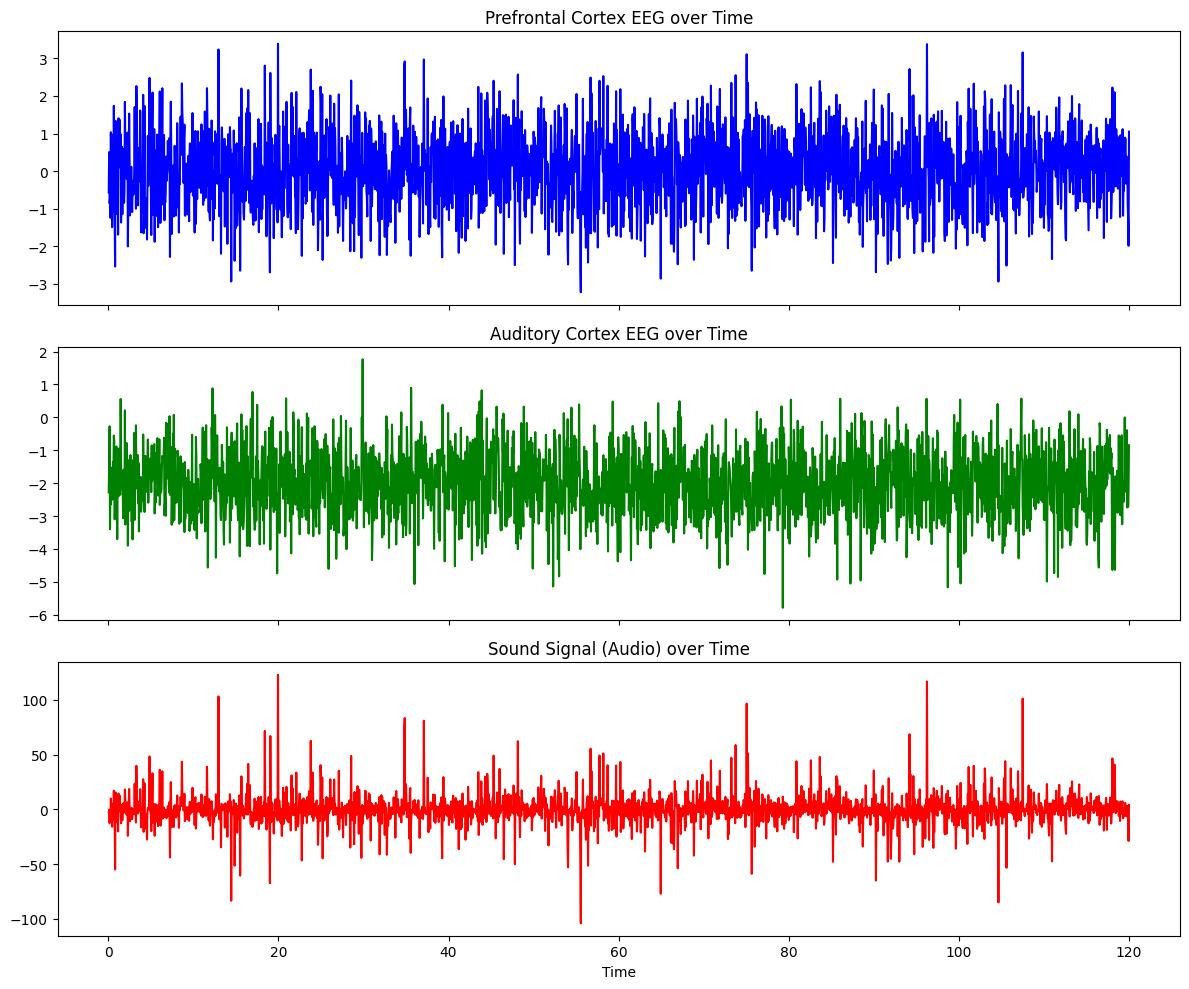

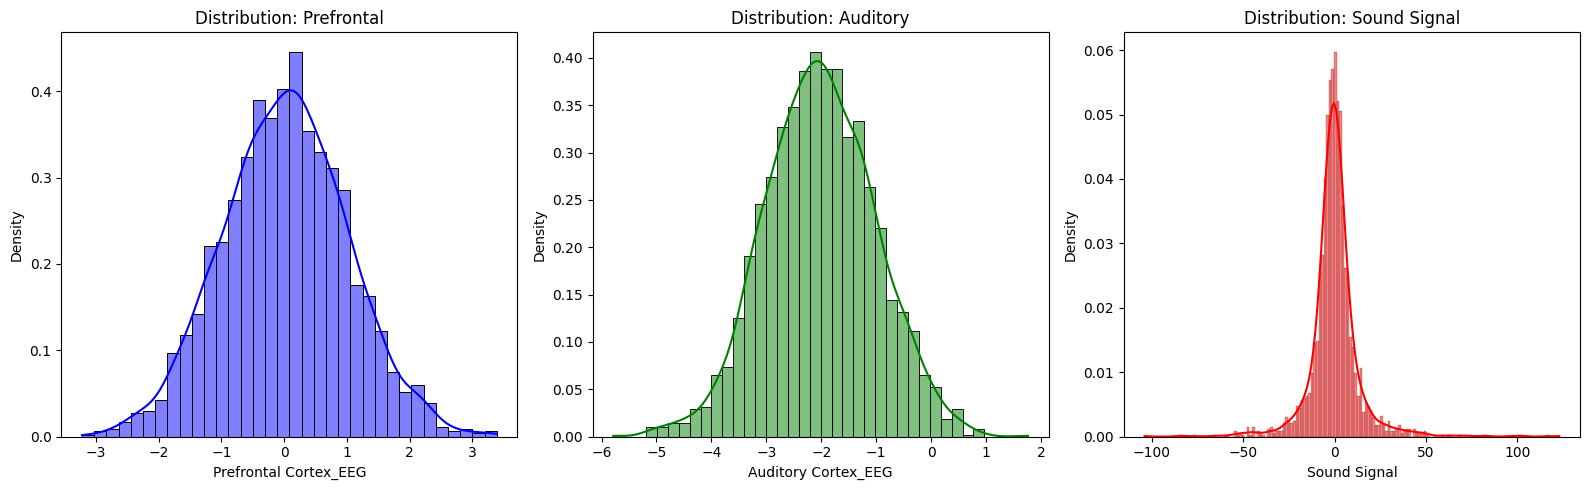

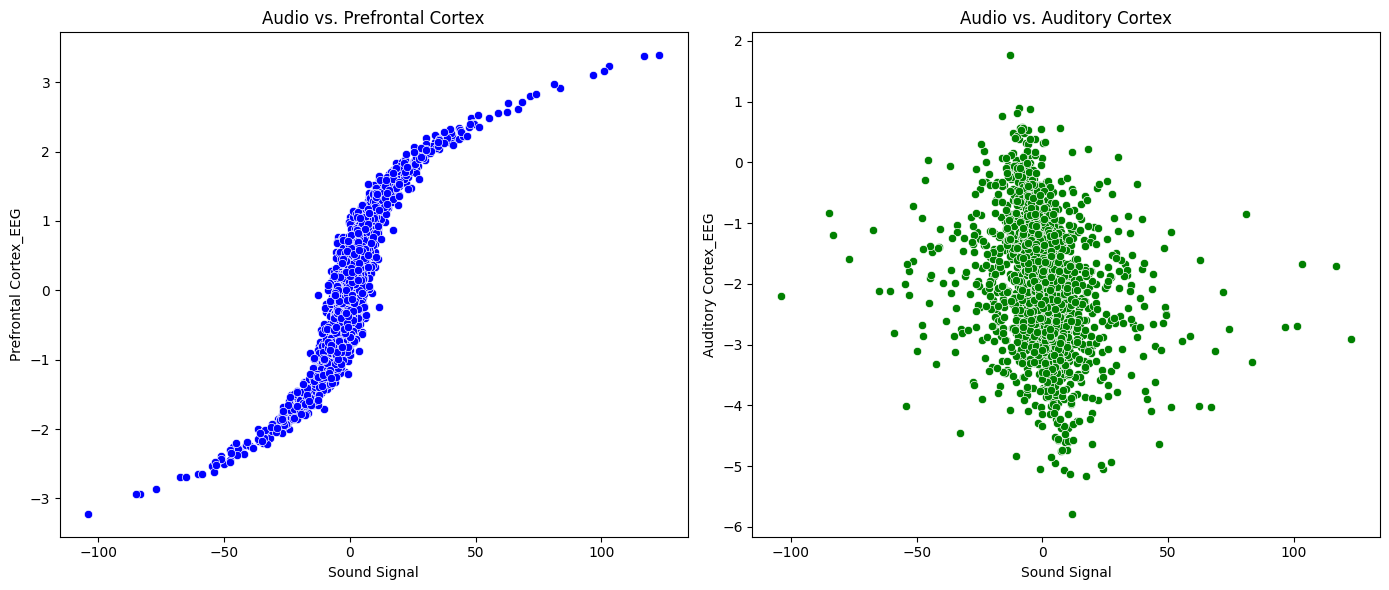

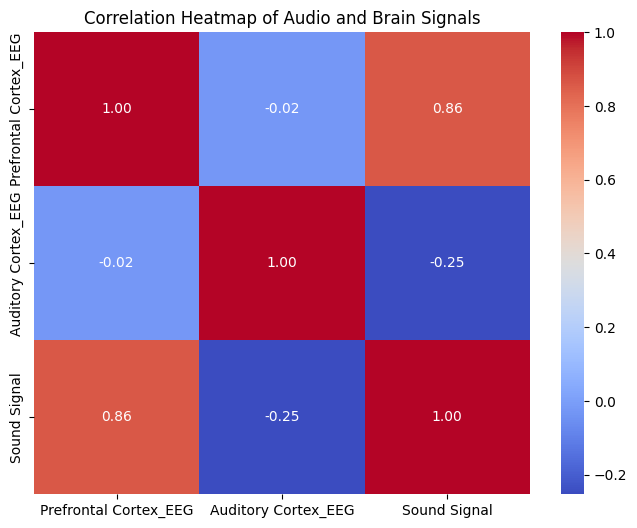

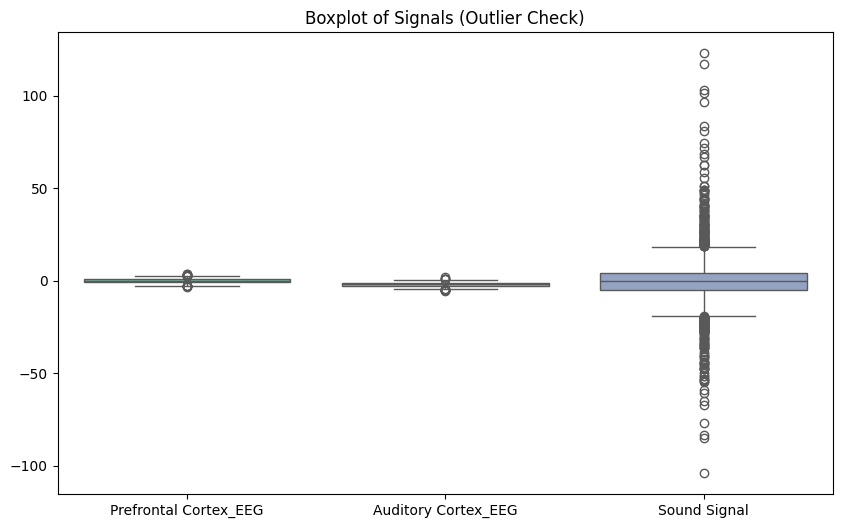

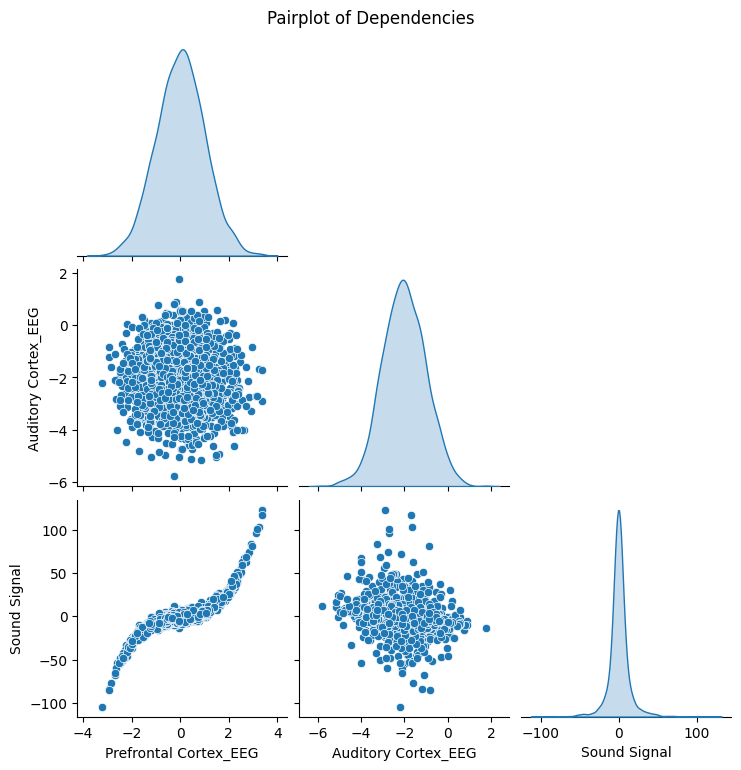

In [ ]:
# 1. Time Series Plots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_eda["Time"], df_eda["Prefrontal Cortex_EEG"], color='blue')
axes[0].set_title("Prefrontal Cortex EEG over Time")

axes[1].plot(df_eda["Time"], df_eda["Auditory Cortex_EEG"], color='green')
axes[1].set_title("Auditory Cortex EEG over Time")

axes[2].plot(df_eda["Time"], df_eda["Sound Signal"], color='red')
axes[2].set_title("Sound Signal (Audio) over Time")

plt.xlabel("Time")
plt.tight_layout()
save_and_track("TimeSeries_All_Signals.png")

# 2. Distribution Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df_eda["Prefrontal Cortex_EEG"], kde=True, ax=axes[0], color='blue', stat='density')
axes[0].set_title("Distribution: Prefrontal")

sns.histplot(df_eda["Auditory Cortex_EEG"], kde=True, ax=axes[1], color='green', stat='density')
axes[1].set_title("Distribution: Auditory")

sns.histplot(df_eda["Sound Signal"], kde=True, ax=axes[2], color='red', stat='density')
axes[2].set_title("Distribution: Sound Signal")

plt.tight_layout()
save_and_track("Distributions_All_Signals.png")

# 3. Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df_eda, x="Sound Signal", y="Prefrontal Cortex_EEG", ax=axes[0], color='blue')
axes[0].set_title("Audio vs. Prefrontal Cortex")

sns.scatterplot(data=df_eda, x="Sound Signal", y="Auditory Cortex_EEG", ax=axes[1], color='green')
axes[1].set_title("Audio vs. Auditory Cortex")

plt.tight_layout()
save_and_track("Scatter_Audio_vs_Brain.png")

# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_eda.iloc[:, 1:4].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Audio and Brain Signals")
save_and_track("Correlation_Heatmap.png")

# 5. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda.iloc[:, 1:4], palette="Set2")
plt.title("Boxplot of Signals (Outlier Check)")
save_and_track("Boxplot_Signals.png")

# 6. Pairplot
sns.pairplot(df_eda.iloc[:, 1:4], diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Dependencies", y=1.02)
save_and_track("Pairplot_Dependencies.png")




### Preliminary data analysis conclusions
The preliminary data analysis provides a comprehensive visual and statistical foundation that strongly supports the researchers' initial hypotheses:

* **Time series & distributions:** The continuous time series plots verify the temporal integrity of the 2-minute recordings. Furthermore, the distribution histograms successfully validate that the underlying additive noise is Gaussian, as the prefrontal, auditory, and sound signal variables consistently exhibit symmetrical, bell-shaped density curves.
* **Prefrontal cortex (Nonlinear):** The scatter plot mapping the Sound Signal against the Prefrontal Cortex EEG reveals a highly distinct "S-shaped" central curve. This visual signature is a classic mathematical indicator of a strong nonlinear dependency, further reinforced by the high positive Pearson correlation coefficient of **0.86**.
* **Auditory cortex (Noisy linear):** Conversely, the Auditory Cortex EEG versus the Sound Signal exhibits a dispersed, scattered cloud lacking any S-curve characteristics. This non-S-shaped clustering reflects the hypothesized linear relationship, though it is visibly heavily obscured by the assumed i.i.d. recording noise. This masking effect results in a very weak linear correlation coefficient of **-0.25**.

In [ ]:
#displaying data in the csv
df.head()

,time,x1,x2,y
0,0.05,-0.562320,-2.274491,-2.386526
1,0.10,0.505550,-1.451586,-0.371560
2,0.15,-0.857812,-0.271215,-12.586452
3,0.20,-0.735262,-3.402501,-0.248121
4,0.25,-1.244369,-2.199162,-10.681437


# Defining the 5 Candidate Models

In [ ]:
# Model 1: y = θ1*x1^3 + θ2*x2^5 + θbias
X1 = np.column_stack((df["x1"]**3, df["x2"]**5, np.ones(len(df["x1"]))))

# Model 2: y = θ1*x1^4 + θ2*x2^2 + θbias
X2 = np.column_stack((df["x1"]**4, df["x2"]**2, np.ones(len(df["x1"]))))

# Model 3: y = θ1*x1^3 + θ2*x2 + θ3*x1 + θbias
X3 = np.column_stack((df["x1"]**3, df["x2"], df["x1"], np.ones(len(df["x1"]))))

# Model 4: y = θ1*x1 + θ2*x1^2 + θ3*x1^3 + θ4*x2^3 + θbias
X4 = np.column_stack((df["x1"], df["x1"]**2, df["x1"]**3, df["x2"]**3, np.ones(len(df["x1"]))))

# Model 5: y = θ1*x1^3 + θ2*x1^4 + θ3*x2 + θbias
X5 = np.column_stack((df["x1"]**3, df["x1"]**4, df["x2"], np.ones(len(df["x1"]))))

# Evaluation of models

# Model 1

Statsmodels Summary:
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.756e+04
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:55:51   Log-Likelihood:                -6465.5
No. Observations:                2400   AIC:                         1.294e+04
Df Residuals:                    2397   BIC:                         1.295e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             3.5967      0.0

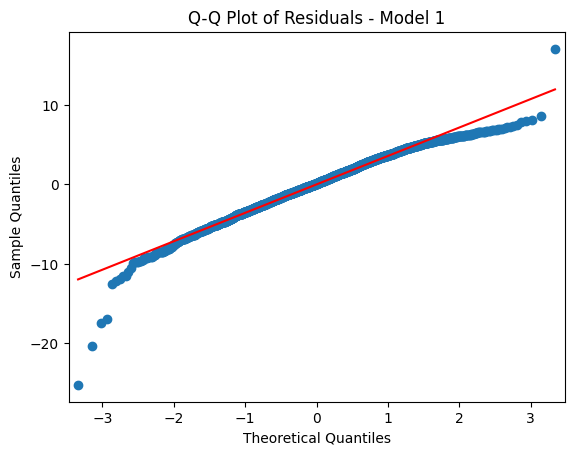

In [ ]:

X = X1
n = len(df["x1"])
y = df["y"]

# Task 2.1: OLS regression model using statsmodels
model = sm.OLS(y, sm.add_constant(X)).fit()
print("Statsmodels Summary:\n", model.summary())

# Task 2.1: Verifying by direct OLS with matrix method: θ = (X^T * X)^-1 * X^T * y
alpha = np.dot((np.dot(np.linalg.inv(np.dot(X.T, X)), X.T)), y)
print("\nDirect Matrix Parameters (Alpha):", alpha)

# Calculating Predictions
yp = np.dot(alpha, X.T)

# Task 2.2 metrics: Computing model residual sum of squared errors (RSS)
rss = np.sum(np.square(y - yp))
print("RSS:", rss)

# Computing the log-likelihood function
llf = -n/2 * log(2*np.pi) - n/2 * log(rss/(n-1)) - (n-1)/2
print("Log-Likelihood:", llf)

# Computing Akaike information criterion (AIC) and Bayesian information criterion (BIC)
k = len(alpha) # Number of parameters
AIC = (2*k) - 2*llf
BIC = k*log(n) - 2*llf
print("AIC:", AIC)
print("BIC:", BIC)

# Task 2.2: Checking distribution of model prediction errors (residuals) using Q-Q plot
res = y - yp
sm.qqplot(np.array(res), line='s')
plt.title("Q-Q Plot of Residuals - Model 1")
save_and_track("QQ_Plot_Model_1.png")

# Model 2

Statsmodels Summary:
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     117.4
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           2.28e-49
Time:                        17:55:58   Log-Likelihood:                -9654.2
No. Observations:                2400   AIC:                         1.931e+04
Df Residuals:                    2397   BIC:                         1.933e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.2743      0.0

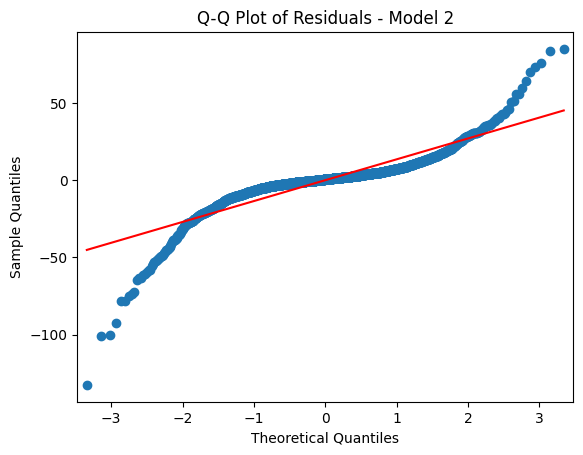

In [ ]:

X = X2
n = len(df["x1"])
y = df["y"]

# Task 2.1: OLS regression model using statsmodels
model = sm.OLS(y, sm.add_constant(X)).fit()
print("Statsmodels Summary:\n", model.summary())

# Task 2.1: Verifying by direct OLS with matrix method: θ = (X^T * X)^-1 * X^T * y
alpha = np.dot((np.dot(np.linalg.inv(np.dot(X.T, X)), X.T)), y)
print("\nDirect Matrix Parameters (Alpha):", alpha)

# Calculating Predictions
yp = np.dot(alpha, X.T)

# Task 2.2 metrics: Computing model residual sum of squared errors (RSS)
rss = np.sum(np.square(y - yp))
print("RSS:", rss)

# Computing the log-likelihood function
llf = -n/2 * log(2*np.pi) - n/2 * log(rss/(n-1)) - (n-1)/2
print("Log-Likelihood:", llf)

# Computing Akaike information criterion (AIC) and Bayesian information criterion (BIC)
k = len(alpha) # Number of parameters
AIC = (2*k) - 2*llf
BIC = k*log(n) - 2*llf
print("AIC:", AIC)
print("BIC:", BIC)

# Task 2.2: Checking distribution of model prediction errors (residuals) using Q-Q plot
res = y - yp
sm.qqplot(np.array(res), line='s')
plt.title("Q-Q Plot of Residuals - Model 2")
save_and_track("QQ_Plot_Model_2.png")

# Model 3

Statsmodels Summary:
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.511e+05
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:56:06   Log-Likelihood:                -2861.8
No. Observations:                2400   AIC:                             5732.
Df Residuals:                    2396   BIC:                             5755.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             2.7157      0.0

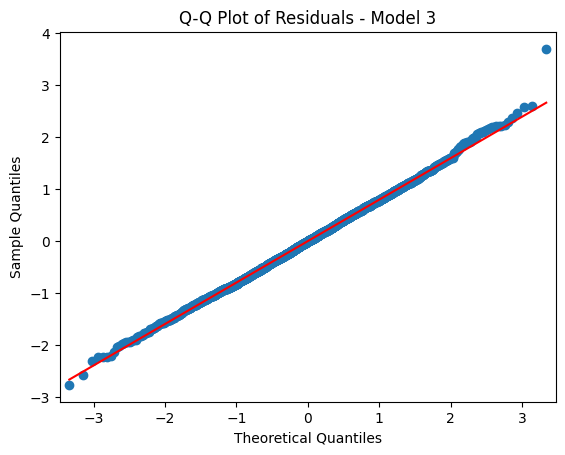

In [ ]:

X = X3
n = len(df["x1"])
y = df["y"]

# Task 2.1: OLS regression model using statsmodels
model = sm.OLS(y, sm.add_constant(X)).fit()
print("Statsmodels Summary:\n", model.summary())

# Task 2.1: Verifying by direct OLS with matrix method: θ = (X^T * X)^-1 * X^T * y
alpha = np.dot((np.dot(np.linalg.inv(np.dot(X.T, X)), X.T)), y)
print("\nDirect Matrix Parameters (Alpha):", alpha)

# Calculating Predictions
yp = np.dot(alpha, X.T)

# Task 2.2 metrics: Computing model residual sum of squared errors (RSS)
rss = np.sum(np.square(y - yp))
print("RSS:", rss)

# Computing the log-likelihood function
llf = -n/2 * log(2*np.pi) - n/2 * log(rss/(n-1)) - (n-1)/2
print("Log-Likelihood:", llf)

# Computing Akaike information criterion (AIC) and Bayesian information criterion (BIC)
k = len(alpha) # Number of parameters
AIC = (2*k) - 2*llf
BIC = k*log(n) - 2*llf
print("AIC:", AIC)
print("BIC:", BIC)

# Task 2.2: Checking distribution of model prediction errors (residuals) using Q-Q plot
res = y - yp
sm.qqplot(np.array(res), line='s')
plt.title("Q-Q Plot of Residuals - Model 3")
save_and_track("QQ_Plot_Model_3.png")

# Model 4

Statsmodels Summary:
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 3.564e+04
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:56:10   Log-Likelihood:                -4842.6
No. Observations:                2400   AIC:                             9695.
Df Residuals:                    2395   BIC:                             9724.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             4.1714      0.0

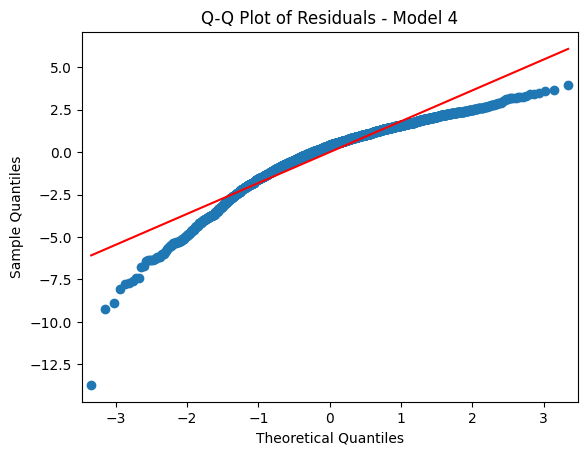

In [ ]:

X = X4
n = len(df["x1"])
y = df["y"]

# Task 2.1: OLS regression model using statsmodels
model = sm.OLS(y, sm.add_constant(X)).fit()
print("Statsmodels Summary:\n", model.summary())

# Task 2.1: Verifying by direct OLS with matrix method: θ = (X^T * X)^-1 * X^T * y
alpha = np.dot((np.dot(np.linalg.inv(np.dot(X.T, X)), X.T)), y)
print("\nDirect Matrix Parameters (Alpha):", alpha)

# Calculating Predictions
yp = np.dot(alpha, X.T)

# Task 2.2 metrics: Computing model residual sum of squared errors (RSS)
rss = np.sum(np.square(y - yp))
print("RSS:", rss)

# Computing the log-likelihood function
llf = -n/2 * log(2*np.pi) - n/2 * log(rss/(n-1)) - (n-1)/2
print("Log-Likelihood:", llf)

# Computing Akaike information criterion (AIC) and Bayesian information criterion (BIC)
k = len(alpha) # Number of parameters
AIC = (2*k) - 2*llf
BIC = k*log(n) - 2*llf
print("AIC:", AIC)
print("BIC:", BIC)

# Task 2.2: Checking distribution of model prediction errors (residuals) using Q-Q plot
res = y - yp
sm.qqplot(np.array(res), line='s')
plt.title("Q-Q Plot of Residuals - Model 4")
save_and_track("QQ_Plot_Model_4.png")

# Model 5

Statsmodels Summary:
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                 2.162e+04
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:56:25   Log-Likelihood:                -5764.5
No. Observations:                2400   AIC:                         1.154e+04
Df Residuals:                    2396   BIC:                         1.156e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             3.6029      0.0

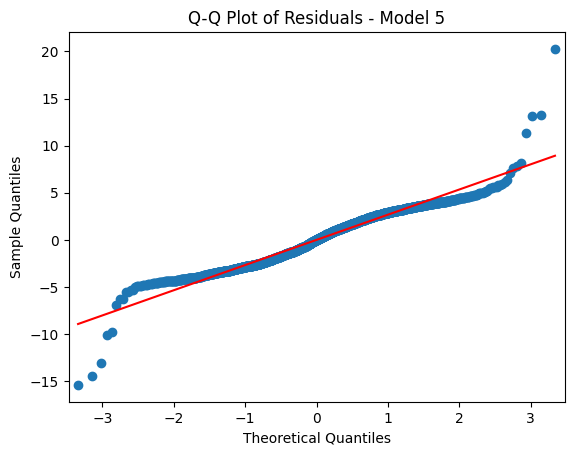

In [ ]:

X = X5
n = len(df["x1"])
y = df["y"]

# Task 2.1: OLS regression model using statsmodels
model = sm.OLS(y, sm.add_constant(X)).fit()
print("Statsmodels Summary:\n", model.summary())

# Task 2.1: Verifying by direct OLS with matrix method: θ = (X^T * X)^-1 * X^T * y
alpha = np.dot((np.dot(np.linalg.inv(np.dot(X.T, X)), X.T)), y)
print("\nDirect Matrix Parameters (Alpha):", alpha)

# Calculating Predictions
yp = np.dot(alpha, X.T)

# Task 2.2 metrics: Computing model residual sum of squared errors (RSS)
rss = np.sum(np.square(y - yp))
print("RSS:", rss)

# Computing the log-likelihood function
llf = -n/2 * log(2*np.pi) - n/2 * log(rss/(n-1)) - (n-1)/2
print("Log-Likelihood:", llf)

# Computing Akaike information criterion (AIC) and Bayesian information criterion (BIC)
k = len(alpha) # Number of parameters
AIC = (2*k) - 2*llf
BIC = k*log(n) - 2*llf
print("AIC:", AIC)
print("BIC:", BIC)

# Task 2.2: Checking distribution of model prediction errors (residuals) using Q-Q plot
res = y - yp
sm.qqplot(np.array(res), line='s')
plt.title("Q-Q Plot of Residuals - Model 5")
save_and_track("QQ_Plot_Model_5.png")

### Model evaluation & Final conclusion

After estimating parameters and calculating evaluation metrics for all five candidate polynomial regression models, **Model 3** is definitively selected as the 'true' mathematical regression model for this dataset.

*  Model 3 demonstrated the lowest scores for both AIC (**5731.54**) and BIC (**5754.67**). Because these criteria apply mathematical penalties for overly complex models, these low scores prove that Model 3 achieves an excellent fit while effectively avoiding overfitting .
* Model 3 yielded the lowest Residual Sum of Squared Errors (RSS: **1525.62**) and the most optimal Log-Likelihood value (**-2861.77**) among all candidates .
*  The Q-Q plot for Model 3 shows the prediction residuals tracking closely along the straight diagonal line, indicating that the remaining prediction errors successfully reflect the expected zero-mean Gaussian noise assumption .

#### The Final Mathematical Model
Using the parameters ($\hat{\theta}$) estimated via the Ordinary Least Squares (OLS) matrix method, the final learned equation is represented as:

$$ y = 2.71x_1^3 - 3.15x_2 + 4.18x_1 - 6.65 $$

This mathematical model accurately captures the underlying neurodynamics by applying a linear term to the auditory cortex ($x_2$) and a nonlinear, cubic formulation to the prefrontal cortex ($x_1^3$), thereby successfully validating the researchers' initial hypothesis.